In [14]:
import pandas as pd
import numpy as np 
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dropout,
    Flatten,
    Dense
)

In [15]:
df = pd.read_csv("fashion-mnist_test.csv")
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [16]:
# 1
X = df.drop('label', axis=1)


X = X / 255.0 # Normalize pixel values to range [0, 1]
y = df['label']

X = np.array(X) # Convert to NumPy arrays
y = np.array(y)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

print("\nFirst 10 normalized pixel values:")
print(X[0][:10])

Shape of X: (10000, 784)
Shape of y: (10000,)

First 10 normalized pixel values:
[0.         0.         0.         0.         0.         0.
 0.         0.03529412 0.03137255 0.        ]


In [17]:
# 2 
X = df.drop("label", axis=1).values
y = df["label"].values
X = X / 255.0
y = to_categorical(y) # convert one-hot encoder
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [18]:
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(784,))) # relu convert output 0 to X 
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax')) # softmax multiclas clscifaction problem  

c:\Users\skadi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [20]:
history = model.fit( X_train,y_train,epochs=10,batch_size=32,validation_split=0.2)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7088 - loss: 0.8153 - val_accuracy: 0.7875 - val_loss: 0.5983
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8127 - loss: 0.5297 - val_accuracy: 0.8356 - val_loss: 0.4935
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8320 - loss: 0.4745 - val_accuracy: 0.8406 - val_loss: 0.4973
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8447 - loss: 0.4262 - val_accuracy: 0.8444 - val_loss: 0.4492
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8622 - loss: 0.3850 - val_accuracy: 0.8631 - val_loss: 0.4141
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8673 - loss: 0.3657 - val_accuracy: 0.8381 - val_loss: 0.4682
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8720 - loss: 0.3504 - val_accuracy: 0.8394 - val_loss: 0.4687
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8791 - loss: 0.3263 - val_accuracy: 0.

In [21]:
loss, accuracy = model.evaluate(X_test, y_test)
print("\nTest Accuracy:", accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8515 - loss: 0.4551  

Test Accuracy: 0.8514999747276306


In [ ]:
# 3 
import pandas as pd
import numpy as np
import tensorflow as tf


X = df.drop("label", axis=1).values
y = df["label"].values
X = X / 255.0

X = X.reshape(-1, 28, 28, 1) # change shap an array
y = to_categorical(y)  

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = Sequential()


model.add(Conv2D(filters=32,kernel_size=(3,3),activation='relu',input_shape=(28,28,1))) # scan image using cond2D 
model.add(MaxPooling2D(pool_size=(2,2))) # reduce image size
model.add(Dropout(0.25))
model.add(Conv2D(filters=64,kernel_size=(3,3),activation='relu'))

model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5)) # remove values 
model.add(Dense(10, activation='softmax'))



model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])


history = model.fit(X_train,y_train,epochs=10,batch_size=32,validation_split=0.2)

loss, accuracy = model.evaluate(X_test, y_test)
print("\nTest Accuracy:", accuracy)

Epoch 1/10


c:\Users\skadi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5747 - loss: 1.1755 - val_accuracy: 0.7794 - val_loss: 0.6354
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7425 - loss: 0.7022 - val_accuracy: 0.7919 - val_loss: 0.5490
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7730 - loss: 0.6028 - val_accuracy: 0.8100 - val_loss: 0.4986
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7933 - loss: 0.5527 - val_accuracy: 0.8350 - val_loss: 0.4655
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8114 - loss: 0.5095 - val_accuracy: 0.8444 - val_loss: 0.4463
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8200 - loss: 0.4813 - val_accuracy: 0.8444 - val_loss: 0.4237
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8327 - loss: 0.4493 - val_accuracy: 0.8612 - val_loss: 0.3915
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8363 - loss: 0.4381 - val_accuracy: 0.8631 - val_

In [ ]:
# 4 
import matplotlib.pyplot as plt



X = df.drop("label", axis=1).values
y = df["label"].values
X = X / 255.0
X = X.reshape(-1, 28, 28, 1)



y = to_categorical(y)
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = Sequential()


model.add(Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))


model.add(Conv2D(64,(3,3),activation='relu'))


model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))


model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(10, activation='softmax'))


model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])


history = model.fit(X_train,y_train,epochs=10,batch_size=32,validation_split=0.2)


loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Accuracy:", accuracy)




Epoch 1/10


c:\Users\skadi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5941 - loss: 1.1047 - val_accuracy: 0.7638 - val_loss: 0.6523
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7472 - loss: 0.6878 - val_accuracy: 0.7956 - val_loss: 0.5513
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7691 - loss: 0.6195 - val_accuracy: 0.8069 - val_loss: 0.5101
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7856 - loss: 0.5642 - val_accuracy: 0.8094 - val_loss: 0.4951
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7970 - loss: 0.5288 - val_accuracy: 0.8431 - val_loss: 0.4599
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8089 - loss: 0.4993 - val_accuracy: 0.8400 - val_loss: 0.4468
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8178 - loss: 0.4830 - val_accuracy: 0.8537 - val_loss: 0.4187
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8364 - loss: 0.4431 - val_accuracy: 0.8519 - val_

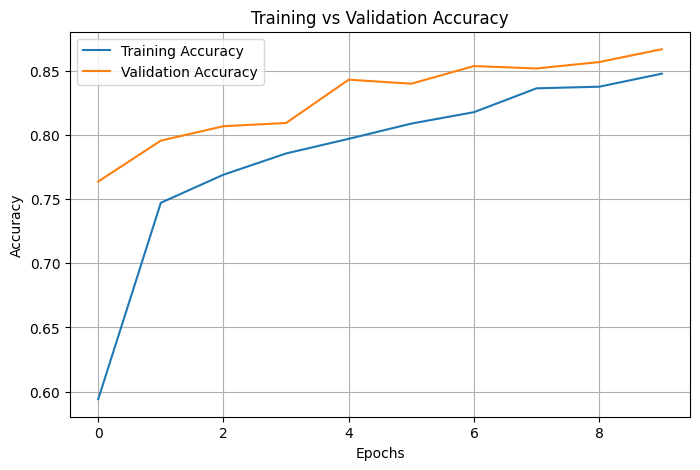

In [24]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)

plt.show()